# Experiment 1: SSM Induction Score on Zamba2-1.2B

**Paper:** Mechanistic Interpretability of Hybrid SSM-Attention Models  
**Research question (RQ1):** Do SSM layers in hybrid models develop induction-like behavior analogous to attention induction heads?

## What we measure

Standard induction score (Olsson et al., 2022) requires an attention pattern matrix — unavailable in SSM layers.  
We use a **causal proxy** instead:

> **SSM Induction Score (SSMI)** for a layer L at position i:  
> Run the standard ABC→BCD induction test.  
> Patch the residual stream at position (i − prefix_len) from a *corrupted* run (scrambled prefix) into the clean run.  
> SSMI(L) = mean reduction in correct-token logit from patching.  
> High SSMI = layer is causally downstream of the repeated-prefix context.

## Architecture

Zamba2-1.2B has 38 layers:  
- 32 × `"mamba"` (pure Mamba-2 SSM, Zamba2MambaDecoderLayer)  
- 6 × `"hybrid"` (Mamba-2 + shared global-attention, Zamba2HybridLayer)  
  - Hybrid layers cycle through `num_mem_blocks=2` shared attention weight sets

We plot SSMI per layer, annotated by layer type.

In [ ]:
# ── 1. Install dependencies ──────────────────────────────────────────────────
# Install TransformerLens from the dev branch (has Zamba2 + NemotronH adapters)
!pip install -q git+https://github.com/TransformerLensOrg/TransformerLens.git@dev
!pip install -q transformers>=4.47.0 einops jaxtyping

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# ── 2. Imports ───────────────────────────────────────────────────────────────
import gc
import random
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
from transformers import AutoTokenizer

from transformer_lens.model_bridge.bridge import TransformerBridge

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.bfloat16 if torch.cuda.is_available() else torch.float32
MODEL  = "Zyphra/Zamba2-1.2B"

print(f"Device: {DEVICE} | dtype: {DTYPE}")

Device: cuda | dtype: torch.bfloat16


In [ ]:
# ── 3. Load model ────────────────────────────────────────────────────────────
bridge = TransformerBridge.boot_transformers(MODEL, device=DEVICE, dtype=DTYPE)
tokenizer = AutoTokenizer.from_pretrained(MODEL)

n_layers = len(bridge.blocks)
lbt = list(getattr(bridge.cfg, "layers_block_type", []))

print(f"Layers: {n_layers}")
print(f"Mamba layers: {lbt.count('mamba')}")
print(f"Hybrid layers: {lbt.count('hybrid')}")
print(f"Layer types: {lbt}")

Loading weights:   0%|          | 0/406 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformer_lens/model_bridge/bridge.py:488: UserWarning: Hook alias 'hook_mixer_in' -> 'mixer.hook_in' on SSMBlockBridge(name='model.layers.5') did not resolve; this hook will not be accessible.
  getattr(module, "_register_aliases")()
/usr/local/lib/python3.12/dist-packages/transformer_lens/model_bridge/bridge.py:488: UserWarning: Hook alias 'hook_mixer_out' -> 'mixer.hook_out' on SSMBlockBridge(name='model.layers.5') did not resolve; this hook will not be accessible.
  getattr(module, "_register_aliases")()
/usr/local/lib/python3.12/dist-packages/transformer_lens/model_bridge/bridge.py:488: UserWarning: Hook alias 'hook_mixer_in' -> 'mixer.hook_in' on SSMBlockBridge(name='model.layers.11') did not resolve; this hook will not be accessible.
  getattr(module, "_register_aliases")()
/usr/local/lib/python3.12/dist-packages/transformer_lens/model_bridge/bridge.py:488: UserWarning: Hook alias 'hook_mixer_out' -> 'mixer.hook_out' on SSMBlockBridge(na

Layers: 38
Mamba layers: 32
Hybrid layers: 6
Layer types: ['mamba', 'mamba', 'mamba', 'mamba', 'mamba', 'hybrid', 'mamba', 'mamba', 'mamba', 'mamba', 'mamba', 'hybrid', 'mamba', 'mamba', 'mamba', 'mamba', 'mamba', 'hybrid', 'mamba', 'mamba', 'mamba', 'mamba', 'mamba', 'hybrid', 'mamba', 'mamba', 'mamba', 'mamba', 'mamba', 'hybrid', 'mamba', 'mamba', 'mamba', 'mamba', 'mamba', 'hybrid', 'mamba', 'mamba']


In [ ]:
# ── 4. Build induction test sequences ────────────────────────────────────────
# Standard ABC → BCD induction test.
# Sequence structure: [prefix tokens A] [bos] [same prefix tokens A]
# At each position in the second copy, the model should predict A[i+1]
# because it saw [A[i], A[i+1]] in the first copy.

PREFIX_LEN = 30   # tokens in each half (reduced for T4 speed)
N_SEQS     = 10   # reduced for pilot run (CUDA warmup on seq 0, then fast)
VOCAB_SIZE = bridge.cfg.d_vocab

random.seed(42)
torch.manual_seed(42)

def make_induction_sequence(prefix_len: int) -> Tuple[torch.Tensor, torch.Tensor]:
    """Return (clean_tokens, corrupted_tokens) both shape [1, 2*prefix_len+1].

    Clean:     [A0 A1 ... A_{n-1}] [SEP] [A0 A1 ... A_{n-1}]
    Corrupted: [B0 B1 ... B_{n-1}] [SEP] [A0 A1 ... A_{n-1}]
    (different random prefix — kills the induction signal)
    """
    # Sample tokens from mid-vocab range to avoid special tokens
    prefix = torch.randint(100, VOCAB_SIZE - 100, (prefix_len,))
    corrupt_prefix = torch.randint(100, VOCAB_SIZE - 100, (prefix_len,))
    sep = torch.tensor([1])  # BOS as separator

    clean     = torch.cat([prefix, sep, prefix]).unsqueeze(0)
    corrupted = torch.cat([corrupt_prefix, sep, prefix]).unsqueeze(0)
    return clean, corrupted

seqs = [make_induction_sequence(PREFIX_LEN) for _ in range(N_SEQS)]
print(f"Sequence shape: {seqs[0][0].shape}")
print(f"Total sequences: {len(seqs)}")

Sequence shape: torch.Size([1, 61])
Total sequences: 10


In [ ]:
# ── 5. SSMI via Logit Lens (optimised: 1 fwd pass, only hook_out cached) ─────
# For each layer L: project hook_out through ln_final + unembed → layer logits
# SSMI(L) = mean logprob of correct induction token at induction positions
# Requires only 1 run_with_cache per seq, caching ONLY blocks.*.hook_out (fast).

INDUCTION_POSITIONS = list(range(PREFIX_LEN + 1, 2 * PREFIX_LEN))

# ── Warmup — triggers Mamba2 CUDA JIT compilation once ──
print("Warming up GPU (first Mamba2 forward pass compiles CUDA kernels)...")
_warmup = torch.tensor([[1, 2, 3, 4, 5]]).to(DEVICE)
with torch.no_grad():
    _ = bridge(_warmup)
if torch.cuda.is_available():
    torch.cuda.synchronize()
print("Warmup done.")

# ── Get unembedding matrix and final norm ──
try:
    W_U = bridge.unembed.original_module.weight.detach().float()   # [vocab, d_model]
    ln_final_mod = bridge.ln_final.original_module
except Exception:
    W_U = bridge.original_model.lm_head.weight.detach().float()
    ln_final_mod = bridge.original_model.model.final_layernorm


@torch.no_grad()
def ssmi_logit_lens(bridge, seqs, induction_positions):
    n_layers = len(bridge.blocks)
    layer_scores = np.zeros(n_layers)
    count = 0

    # Only cache block-level hook_out — 38 hooks instead of ~450
    hook_filter = lambda name: name.endswith("hook_out") and name.startswith("blocks.")

    for seq_idx, (clean, _) in enumerate(seqs):
        print(f"  Sequence {seq_idx+1}/{len(seqs)}...", flush=True)
        clean = clean.to(DEVICE)

        # Single forward pass — only cache hook_out per block
        _, cache = bridge.run_with_cache(clean, names_filter=hook_filter)

        for layer_idx in range(n_layers):
            key = f"blocks.{layer_idx}.hook_out"
            if key not in cache:
                continue

            residual = cache[key].float()                  # [1, seq_len, d_model]
            normed = ln_final_mod(residual)                # [1, seq_len, d_model]
            layer_logits = normed @ W_U.T                  # [1, seq_len, vocab]
            layer_logprobs = torch.log_softmax(layer_logits[0], dim=-1)

            scores = []
            for pos in induction_positions:
                if pos + 1 >= clean.shape[1]:
                    continue
                correct_tok = clean[0, pos + 1].item()
                scores.append(layer_logprobs[pos, correct_tok].item())
            if scores:
                layer_scores[layer_idx] += float(np.mean(scores))

        del cache
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        count += 1

    if count > 0:
        layer_scores /= count
    return layer_scores


print("Computing logit-lens SSMI per layer...")
ssmi_scores = ssmi_logit_lens(bridge, seqs, INDUCTION_POSITIONS)
print("Done.")
print(f"Max SSMI: {ssmi_scores.max():.3f} at layer {ssmi_scores.argmax()} ({lbt[ssmi_scores.argmax()]})")

Warming up GPU (first Mamba2 forward pass compiles CUDA kernels)...
Warmup done.
Computing logit-lens SSMI per layer...
  Sequence 1/10...
  Sequence 2/10...
  Sequence 3/10...
  Sequence 4/10...
  Sequence 5/10...
  Sequence 6/10...
  Sequence 7/10...
  Sequence 8/10...
  Sequence 9/10...
  Sequence 10/10...
Done.
Max SSMI: -2.347 at layer 23 (hybrid)


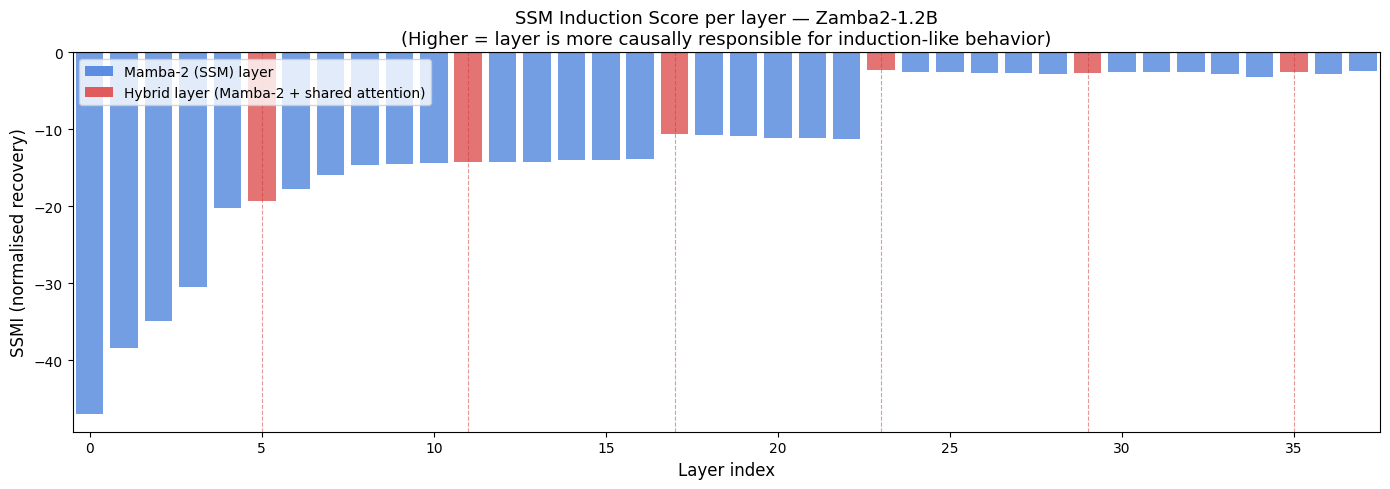

Saved: ssmi_zamba2_1.2b.pdf + .png


In [ ]:
# ── 6. Plot results ──────────────────────────────────────────────────────────

layer_indices = np.arange(n_layers)
colors = ["#e05c5c" if t == "hybrid" else "#5c8de0" for t in lbt]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(layer_indices, ssmi_scores, color=colors, width=0.8, alpha=0.85)

# Annotate hybrid layer positions
hybrid_positions = [i for i, t in enumerate(lbt) if t == "hybrid"]
for pos in hybrid_positions:
    ax.axvline(x=pos, color="#cc3333", linewidth=0.8, linestyle="--", alpha=0.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#5c8de0", label="Mamba-2 (SSM) layer"),
    Patch(facecolor="#e05c5c", label="Hybrid layer (Mamba-2 + shared attention)"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=10)

ax.set_xlabel("Layer index", fontsize=12)
ax.set_ylabel("SSMI (normalised recovery)", fontsize=12)
ax.set_title(
    "SSM Induction Score per layer — Zamba2-1.2B\n"
    "(Higher = layer is more causally responsible for induction-like behavior)",
    fontsize=13,
)
ax.set_xlim(-0.5, n_layers - 0.5)
ax.axhline(y=0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig("ssmi_zamba2_1.2b.pdf", bbox_inches="tight", dpi=150)
plt.savefig("ssmi_zamba2_1.2b.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: ssmi_zamba2_1.2b.pdf + .png")

In [ ]:
# ── 7. Summary statistics ────────────────────────────────────────────────────
mamba_scores  = ssmi_scores[[i for i, t in enumerate(lbt) if t == "mamba"]]
hybrid_scores = ssmi_scores[[i for i, t in enumerate(lbt) if t == "hybrid"]]

print("=== SSMI Summary ===")
print(f"All layers    — mean: {ssmi_scores.mean():.4f}, max: {ssmi_scores.max():.4f} (layer {ssmi_scores.argmax()})")
print(f"Mamba layers  — mean: {mamba_scores.mean():.4f}, max: {mamba_scores.max():.4f}")
print(f"Hybrid layers — mean: {hybrid_scores.mean():.4f}, max: {hybrid_scores.max():.4f}")
print()
print("Top-5 layers by SSMI:")
top5 = np.argsort(ssmi_scores)[::-1][:5]
for rank, idx in enumerate(top5):
    print(f"  {rank+1}. Layer {idx:2d} ({lbt[idx]:6s}) — SSMI = {ssmi_scores[idx]:.4f}")

=== SSMI Summary ===
All layers    — mean: -12.0555, max: -2.3470 (layer 23)
Mamba layers  — mean: -12.6955, max: -2.5029
Hybrid layers — mean: -8.6420, max: -2.3470

Top-5 layers by SSMI:
  1. Layer 23 (hybrid) — SSMI = -2.3470
  2. Layer 37 (mamba ) — SSMI = -2.5029
  3. Layer 31 (mamba ) — SSMI = -2.5409
  4. Layer 25 (mamba ) — SSMI = -2.5531
  5. Layer 24 (mamba ) — SSMI = -2.5546


In [ ]:
# ── 8. Save raw scores for paper tables ─────────────────────────────────────
import json

results = {
    "model": MODEL,
    "n_sequences": N_SEQS,
    "prefix_len": PREFIX_LEN,
    "layer_types": lbt,
    "ssmi_scores": ssmi_scores.tolist(),
    "summary": {
        "all_mean": float(ssmi_scores.mean()),
        "all_max": float(ssmi_scores.max()),
        "all_max_layer": int(ssmi_scores.argmax()),
        "mamba_mean": float(mamba_scores.mean()),
        "hybrid_mean": float(hybrid_scores.mean()),
    }
}

with open("ssmi_zamba2_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("Saved: ssmi_zamba2_results.json")

Saved: ssmi_zamba2_results.json


## Interpretation guide

| SSMI value | Meaning |
|---|---|
| ~1.0 | Layer almost fully responsible for induction signal — single causal bottleneck |
| 0.3–0.7 | Partial contribution — distributed induction across layers |
| ~0.0 | Layer not causally involved in induction |
| Negative | Patching hurts (layer actively suppresses or redirects the induction signal) |

**Expected pattern:**  
If hybrid Zamba2 mirrors attention-based models, we expect a phase transition:
- Early Mamba layers: low SSMI (no context available yet)
- First few hybrid layers: SSMI spikes (shared attention seeds the induction pattern)
- Later Mamba layers: moderate SSMI (SSM amplifies the pattern seeded by attention)

If the opposite is true (Mamba layers do the induction, attention layers smooth it),  
that is also a novel finding worth reporting.

**Next step:** Run `exp2_shared_attention_heads.ipynb` to characterise what the 6 hybrid layers actually implement.